# Investigation 07: Specific Rule Search and Area Exclusion

This notebook allows you to search for a specific rule within a specific organ and stage cohort. 
It iterates through *all* FOVs in that cohort, computing the raw spatial metrics (Support, Confidence, Lift) from scratch. It evaluates how many FOVs pass the defined thresholds, and then re-evaluates the entire cohort *after* completely excluding cells from specified spatial areas (e.g., `in_SMV`, `in_Muscle`). 

It also plots a representative FOV showing a progression as areas are excluded, highlighting rule cells with a red border if they fall within an excluded zone.

## 1. Configuration & Imports

In [15]:
import ast
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../../'))
from spatial_association_rules import is_crowded_by_one_type
# --- self-contained helpers (this notebook studies marker rules, which the pipeline no longer builds) ---
def build_cell_item_token(cell_type, subtypes, suffix=None):
    """One label per cell: type plus any markers, e.g. 'CD8T_CD103+_CENTER'."""
    base = str(cell_type)
    markers = sorted({str(s)[len(base) + 1:] if str(s).startswith(base + "_") else str(s)
                      for s in (subtypes if subtypes is not None else [])})
    core = f"{base}_{'_'.join(markers)}" if markers else base
    return f"{core}_{suffix}" if suffix else core


def _extract_base_lineage(item):
    """'Neutrophil_CD15_Ki67+_NEIGHBOR' -> 'Neutrophil_CD15'."""
    clean = item.replace("_CENTER", "").replace("_NEIGHBOR", "")
    if "+" not in clean:
        return clean
    parts = [p for p in clean.split("_") if "+" not in p]
    return "_".join(parts) if parts else clean


def passes_rule_support_policy(config, support, sup_ant, sup_con, confidence, lift, num_transactions):
    """Avoidance waives joint support; high confidence earns a lower floor."""
    floor = float(config.get("MIN_ABS_SUPPORT", 0)) / float(num_transactions)
    if lift < 1.0:
        return sup_ant >= floor and sup_con >= floor
    needed = config.get("HIGH_CONF_MIN_SUPPORT", config["MIN_SUPPORT"]) \
        if confidence >= config.get("HIGH_CONFIDENCE_THRESHOLD", 1.01) else config["MIN_SUPPORT"]
    return support >= max(needed, floor)

# ==========================================
# CONSTANTS & CONFIGURATION
# ==========================================

USE_FUNCTIONAL_MARKERS = True
CELLTYPE_MARKER_THRESHOLDS = {
    'Epithelial': {'Ki67': 2.5, 'HLADRDPDQ': 1.75},
    'CD8T': {'Ki67': 2.5, 'CD103': 2.0, 'CD69': 2.0, 'GZMB': 2.5},
    'CD4T': {'Ki67': 1.0, 'CD103': 1.0, 'CD69': 2.0, 'GZMB': 0.5},
    'Neutrophil': {'CD103': 2.75},
    'Neutrophil_CD15': {'CD103': 2.75}
}

CONFIG = {
    'RADIUS': 25.0,
    'BANDWIDTH': 15.0,
    'MIN_SUPPORT': 0.01,
    'MIN_CONFIDENCE': 0.3,
    'MIN_LIFT': 1.2,
    'MIN_CELLS_PER_PATCH': 2
}

RADIUS = CONFIG['RADIUS']
BANDWIDTH = CONFIG['BANDWIDTH']
MIN_SUPPORT = CONFIG['MIN_SUPPORT']
MIN_CONFIDENCE = CONFIG['MIN_CONFIDENCE']
MIN_LIFT = CONFIG['MIN_LIFT']
MIN_CELLS_PER_PATCH = CONFIG['MIN_CELLS_PER_PATCH']


## 2. Data Loading & Preprocessing

In [16]:
def _add_functional_subtypes(df):
    if not USE_FUNCTIONAL_MARKERS:
        df["functional_subtypes"] = [[] for _ in range(len(df))]
        return df
    functional_subtypes_list = [[] for _ in range(len(df))]
    idx_to_pos = {idx: i for i, idx in enumerate(df.index)}
    for base_type, markers in CELLTYPE_MARKER_THRESHOLDS.items():
        type_mask = df["cell type"] == base_type
        for marker, threshold in markers.items():
            if marker in df.columns:
                mask = type_mask & (df[marker] > threshold)
                subtype_label = f"{base_type}_{marker}+"
                matching_indices = df.index[mask]
                for idx in matching_indices:
                    functional_subtypes_list[idx_to_pos[idx]].append(subtype_label)
    df["functional_subtypes"] = functional_subtypes_list
    return df

def load_datasets():
    print("Finding and loading datasets... this might take a minute.")
    
    # 1. Resolve Data Path
    current_dir = os.path.abspath(os.getcwd())
    while current_dir != os.path.dirname(current_dir):
        potential_data = os.path.join(current_dir, 'data', 'MIBIGutCsv')
        if os.path.exists(potential_data):
            break
        current_dir = os.path.dirname(current_dir)
    data_dir = potential_data if os.path.exists(potential_data) else '../../data/MIBIGutCsv'
    
    # 2. Load Raw Tables
    df_cells = pd.read_csv(os.path.join(data_dir, 'cell_table.csv'))
    df_fovs = pd.read_csv(os.path.join(data_dir, 'fovs_metadata.csv'))
    df_biopsy = pd.read_csv(os.path.join(data_dir, 'biopsy_metadata.csv'))
    
    # 3. Merge Metadata
    df_fovs = pd.merge(df_fovs, df_biopsy[['Biopsy_ID', 'Pathological score', 'Localization']], left_on='Patient', right_on='Biopsy_ID', how='left')
    
    # 4. Standardize Organ Name
    def get_organ(row):
        if pd.notna(row.get("Localization")): 
            return row["Localization"]
        cohort = str(row.get("Cohort", ""))
        if "Colon" in cohort: return "Colon"
        if "Duodenum" in cohort: return "Duodenum"
        return "Unknown"
    df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)
    
    # 5. Standardize Stage (Splitting Control vs Control_S)
    def get_stage(row):
        score = row.get("Pathological score")
        if pd.isna(score) or score == "Control":
            if str(row["FOV"]).startswith("S_"):
                return "Control_S"
            else:
                return "Control"
        return str(score)
    df_fovs["Stage"] = df_fovs.apply(get_stage, axis=1)
    
    # 6. Normalize Coordinates
    fov_to_size = df_fovs.set_index('FOV')['Size [um]'].to_dict()
    def normalize_coords(row):
        size = fov_to_size.get(row['fov'], 800)
        res = 1024 if size == 400 else 2048
        return row['centroid_x'] * (size / res), row['centroid_y'] * (size / res)
    df_cells[['x_um', 'y_um']] = df_cells.apply(lambda row: pd.Series(normalize_coords(row)), axis=1)
    
    # 7. Add Functional Subtypes
    df_cells = _add_functional_subtypes(df_cells)
        
    return df_cells, df_fovs

# Execute loading
df_cells, df_fovs = load_datasets()
print(f"Loaded {len(df_cells)} cells and {len(df_fovs)} FOVs.")


Finding and loading datasets... this might take a minute.
Loaded 713372 cells and 288 FOVs.


## 3. Plotting & Visualization Setup

In [17]:
# Prepare colors for consistent cell plotting
all_types = sorted(df_cells["cell type"].dropna().astype(str).unique())
try:
    palette = plt.colormaps.get_cmap("tab20b").resampled(max(len(all_types), 1))
except AttributeError:
    palette = plt.cm.get_cmap("tab20b", max(len(all_types), 1))
CELL_COLOR_MAP = {ct: palette(i) for i, ct in enumerate(all_types)}
OTHER_COLOR = (0.5, 0.5, 0.5)

def add_scale_bar(ax, x_max, y_max):
    """Adds a 50µm scale bar to the bottom right of the plot."""
    bar_um = 50.0
    x_end = x_max - 25
    x_start = x_end - bar_um
    y_line = y_max - 25
    ax.plot([x_start, x_end], [y_line, y_line], color="black", linewidth=4, solid_capstyle="butt")
    ax.text((x_start + x_end) / 2, y_line - 12, "50 µm", color="black", ha="center", va="bottom", fontsize=10)

def plot_single_fov(ax, df_fov, title, size_um, target_cells=None, highlight_indices=None, custom_target_mask=None):
    """
    Draws a single FOV cleanly.
    - target_cells: If provided, only these cells are colored. The rest are grayed out.
    - custom_target_mask: If provided, only cells where this mask is True are colored. The rest are grayed out.
    - highlight_indices: Cell indices to draw with a thick red border.
    """
    cell_size = 90 if size_um == 400 else 45
    ax.set_facecolor("#eaeaeaff")
    
    # Prepare highlight mask
    if highlight_indices is not None and len(highlight_indices) > 0:
        highlight_mask = df_fov.index.isin(highlight_indices)
    else:
        highlight_mask = pd.Series(False, index=df_fov.index)
        
    if target_cells is not None or custom_target_mask is not None:
        if custom_target_mask is not None:
            target_mask = custom_target_mask & ~highlight_mask
            other_mask = ~custom_target_mask & ~highlight_mask
            present_types = sorted(df_fov[target_mask]["cell type"].dropna().astype(str).unique())
            handles_cells = present_types
        else:
            target_mask = df_fov['cell type'].isin(target_cells) & ~highlight_mask
            other_mask = ~df_fov['cell type'].isin(target_cells) & ~highlight_mask
            handles_cells = target_cells
            
        # Plot background "Other" cells
        if other_mask.any():
            g = df_fov[other_mask]
            ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[OTHER_COLOR], alpha=0.3, linewidths=0, label='Other')
            
        # Plot target cells
        if target_mask.any():
            for ct, g in df_fov[target_mask].groupby("cell type"):
                color = CELL_COLOR_MAP.get(ct, (0, 0, 0))
                ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[color], label=ct, alpha=0.9, linewidths=0)
                
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=CELL_COLOR_MAP.get(ct, 'black'), markeredgecolor="none", markersize=8, label=ct) for ct in handles_cells]
        
    else:
        # Plot all normal cells in full color
        for ct, g in df_fov[~highlight_mask].groupby("cell type"):
            color = CELL_COLOR_MAP.get(ct, (1, 1, 1))
            ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[color], label=ct, alpha=0.9, linewidths=0)
            
        present_types = sorted(df_fov[~highlight_mask]["cell type"].dropna().astype(str).unique())
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=CELL_COLOR_MAP.get(ct, 'black'), markeredgecolor="none", markersize=8, label=ct) for ct in present_types]

    # Plot highlighted cells (Red Border) on top of everything
    if highlight_mask.any():
        for ct, g in df_fov[highlight_mask].groupby("cell type"):
            color = CELL_COLOR_MAP.get(ct, (0, 0, 0))
            ax.scatter(g["x_um"], g["y_um"], s=cell_size, c=[color], alpha=0.9, edgecolors='red', linewidths=2)
            
    # Standardize grid and scale
    x_max, y_max = size_um, size_um
    grid_spacing = 25.0
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MultipleLocator(100.0))
    ax.yaxis.set_major_locator(MultipleLocator(100.0))
    ax.xaxis.set_minor_locator(MultipleLocator(grid_spacing))
    ax.yaxis.set_minor_locator(MultipleLocator(grid_spacing))
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8, alpha=0.7)
    ax.grid(which="major", color="lightgray", linestyle="-", linewidth=0.8, alpha=0.8)
    
    add_scale_bar(ax, x_max=x_max, y_max=y_max)
    
    ax.set_title(title, color="black", fontsize=14)
    ax.set_xlabel("x (µm)", color="black")
    ax.set_ylabel("y (µm)", color="black")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.tick_params(axis="both", colors="black", labelsize=9)
    for spine in ax.spines.values(): spine.set_visible(False)

    ax.legend(handles=handles, title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, frameon=True)

def plot_exclusion_progression(target_fov, target_cells, excluded_areas):
    """
    Creates a side-by-side progression plot showing cumulative exclusions.
    """
    df_fov_all = df_cells[df_cells["fov"] == target_fov].copy()
    if df_fov_all.empty:
        print(f"No cells found for FOV {target_fov}")
        return
        
    size_um = df_fovs[df_fovs['FOV'] == target_fov]['Size [um]'].iloc[0] if not df_fovs[df_fovs['FOV'] == target_fov].empty else 400
    
    # Calculate number of plots: 1 (Full) + 1 (Excluded cells only) + len(excluded_areas) (Cumulative exclusions) + 1 (Rule cells only)
    num_plots = 1 + 1 + len(excluded_areas) + 1
    
    # Layout up to 3 columns per row
    cols = min(3, num_plots)
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 10 * rows), facecolor="#ffffff")
    axes = np.atleast_1d(axes).flatten()
    plot_idx = 0
    
    # Plot A: Full FOV
    plot_single_fov(axes[plot_idx], df_fov_all, f"Full FOV: {target_fov}", size_um)
    plot_idx += 1
    
    # Plot B: Excluded Cells Only
    overall_excluded_mask = pd.Series(False, index=df_fov_all.index)
    for area in excluded_areas:
        if area in df_fov_all.columns:
            overall_excluded_mask = overall_excluded_mask | (df_fov_all[area] == 1)
            
    title_excluded_only = f"Excluded Cells Only\n({', '.join(excluded_areas)})"
    plot_single_fov(axes[plot_idx], df_fov_all, title_excluded_only, size_um, custom_target_mask=overall_excluded_mask)
    plot_idx += 1
    
    # Plot C... : Cumulative Exclusions
    current_df = df_fov_all.copy()
    cumulative_areas = []
    
    for area in excluded_areas:
        cumulative_areas.append(area)
        if area in current_df.columns:
            current_df = current_df[current_df[area] != 1]
            
        title = f"Excluding: {', '.join(cumulative_areas)}"
        plot_single_fov(axes[plot_idx], current_df, title, size_um)
        plot_idx += 1
        
    # Last Plot: Highlighted Rule Cells Only
    rule_cells_df = df_fov_all[df_fov_all['cell type'].isin(target_cells)]
    
    rule_excluded_mask = pd.Series(False, index=rule_cells_df.index)
    for area in excluded_areas:
        if area in rule_cells_df.columns:
            rule_excluded_mask = rule_excluded_mask | (rule_cells_df[area] == 1)
            
    highlight_indices = rule_cells_df[rule_excluded_mask].index
    
    final_plot_df = df_fov_all.copy()
    final_excluded_mask = pd.Series(False, index=final_plot_df.index)
    for area in excluded_areas:
        if area in final_plot_df.columns:
            final_excluded_mask = final_excluded_mask | (final_plot_df[area] == 1)
            
    non_rule_excluded = final_excluded_mask & ~final_plot_df['cell type'].isin(target_cells)
    final_plot_df = final_plot_df[~non_rule_excluded]
    
    title_final = f"Rule Cells Only\nRed border = Rule cell in excluded area"
    plot_single_fov(axes[plot_idx], final_plot_df, title_final, size_um, target_cells=target_cells, highlight_indices=highlight_indices)
    plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].axis('off')
        
    # Add A, B, C, D... lettering
    for i in range(plot_idx):
        ax = axes[i]
        letter = chr(65 + i)
        ax.text(-0.05, 1.05, letter, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')
        
    plt.tight_layout()
    plt.show()


## 4. Rule Calculation Logic (Weighted FP-Growth Approach)

In [18]:
def _matches_rule_item(token, base, suffix, required_markers=()):
    token = str(token)
    tail = f"_{suffix}"
    if not token.endswith(tail):
        return False
        
    core = token[:-len(tail)]
    token_base = _extract_base_lineage(core)
    token_markers = {part for part in core.split('_') if part.endswith('+')}
    
    if token_base != base:
        return False
    return set(required_markers).issubset(token_markers)

def _weight_for_item(weighted_trans, base, suffix, required_markers=()):
    return min(
        sum(float(v) for k, v in weighted_trans.items() if _matches_rule_item(k, base, suffix, required_markers)),
        1.0,
    )

def calculate_weighted_metrics_for_fov(df_fov, ant_base, con_base, ant_markers=(), con_markers=()):
    """
    Calculates the spatial Support, Confidence, and Lift for a rule inside a specific FOV 
    using distance-decay weights.
    """
    if df_fov.empty:
        return 0, 0, 0, 0
        
    coords = df_fov[['x_um', 'y_um']].values
    types = df_fov['cell type'].values
    subtypes = df_fov['functional_subtypes'].values
    
    if len(coords) < MIN_CELLS_PER_PATCH:
        return 0, 0, 0, 0

    # Build Spatial Network
    nn = NearestNeighbors(radius=RADIUS).fit(coords)
    distances, neighbors_idx = nn.radius_neighbors(coords, return_distance=True)

    fov_weighted_trans = []

    for i, (idxs, dists) in enumerate(zip(neighbors_idx, distances)):
        if len(idxs) < MIN_CELLS_PER_PATCH:
            continue
            
        # Artifact check
        raw_types = types[idxs]
        if is_crowded_by_one_type(raw_types, 0.9):
            continue

        center_token = build_cell_item_token(types[i], subtypes[i], suffix='CENTER')
        w_trans = {center_token: 1.0}

        for n_idx, d in zip(idxs, dists):
            if n_idx == i:
                continue
            
            neighbor_token = build_cell_item_token(types[n_idx], subtypes[n_idx], suffix='NEIGHBOR')
            w = np.exp(-0.5 * (d / BANDWIDTH) ** 2)
            w_trans[neighbor_token] = w_trans.get(neighbor_token, 0.0) + w

        w_trans = {k: min(v, 1.0) for k, v in w_trans.items()}
        fov_weighted_trans.append(w_trans)

    n_trans = len(fov_weighted_trans)
    if n_trans == 0:
        return 0, 0, 0, 0

    w_sup_ant = sum(
        _weight_for_item(t, ant_base, 'CENTER', ant_markers)
        for t in fov_weighted_trans
    ) / n_trans
    
    w_sup_con = sum(
        _weight_for_item(t, con_base, 'NEIGHBOR', con_markers)
        for t in fov_weighted_trans
    ) / n_trans
    
    w_sup_joint = sum(
        min(
            _weight_for_item(t, ant_base, 'CENTER', ant_markers),
            _weight_for_item(t, con_base, 'NEIGHBOR', con_markers),
        )
        for t in fov_weighted_trans
    ) / n_trans

    w_conf = w_sup_joint / w_sup_ant if w_sup_ant > 0 else 0
    w_lift = w_conf / w_sup_con if w_sup_con > 0 else 0

    return n_trans, w_sup_joint, w_conf, w_lift


## 5. Main Orchestrator

In [19]:
def evaluate_cohort_and_exclusion(ant_base, con_base, excluded_areas, organ, stage, ant_markers=(), con_markers=()):
    """
    1. Iterates over ALL FOVs in the given Organ and Stage cohort.
    2. Computes per-FOV metrics BEFORE exclusion and checks if they pass thresholds.
    3. Computes per-FOV metrics AFTER excluding cells in specified areas.
    4. Prints a comparison summary.
    5. Plots progression for the FOV that had the highest rule presence initially.
    """
    print(f"============================================================")
    print(f"Investigating Rule: {ant_base} -> {con_base}")
    print(f"Organ: {organ} | Stage: {stage}")
    print(f"Excluded Areas: {excluded_areas}")
    print(f"============================================================\n")
    
    # 1. Get Cohort FOVs
    target_fovs_metadata = df_fovs[(df_fovs["Organ"] == organ) & (df_fovs["Stage"] == stage)]
    valid_fov_names = target_fovs_metadata["FOV"].tolist()
    
    if not valid_fov_names:
        print(f"No FOVs found for {organ} / {stage}.")
        return
        
    print(f"Evaluating {len(valid_fov_names)} FOVs...\n")
    
    # Trackers
    valid_fov_count = 0
    orig_pass_count = 0
    excl_pass_count = 0
    
    orig_passed_metrics = []
    excl_passed_metrics = []
    
    max_target_count = -1
    max_target_fov = None
    
    # 2. Iterate FOVs
    for fov in valid_fov_names:
        df_fov_all = df_cells[df_cells["fov"] == fov].copy()
        if df_fov_all.empty:
            continue
        valid_fov_count += 1

        # Find FOV with most antecedent cells for plotting later
        ant_count = sum(1 for t, st in zip(df_fov_all['cell type'], df_fov_all['functional_subtypes']) 
                        if _matches_rule_item(build_cell_item_token(t, st, suffix='CENTER'), ant_base, 'CENTER', ant_markers))
        if ant_count > max_target_count:
            max_target_count = ant_count
            max_target_fov = fov
            
        # --- BEFORE EXCLUSION ---
        n_trans, s, c, l = calculate_weighted_metrics_for_fov(df_fov_all, ant_base, con_base, ant_markers, con_markers)
        
        orig_pass = False
        if s >= MIN_SUPPORT and c >= MIN_CONFIDENCE and l >= MIN_LIFT:
            orig_pass = True
            orig_pass_count += 1
            orig_passed_metrics.append((s, c, l))
            
        # --- AFTER EXCLUSION ---
        df_fov_excl = df_fov_all.copy()
        for area in excluded_areas:
            if area in df_fov_excl.columns:
                df_fov_excl = df_fov_excl[df_fov_excl[area] != 1]
                
        ex_n_trans, es, ec, el = calculate_weighted_metrics_for_fov(df_fov_excl, ant_base, con_base, ant_markers, con_markers)
        
        excl_pass = False
        if es >= MIN_SUPPORT and ec >= MIN_CONFIDENCE and el >= MIN_LIFT:
            excl_pass = True
            excl_pass_count += 1
            excl_passed_metrics.append((es, ec, el))
            
        print(f"FOV: {fov}")
        print(f"  [Orig] Trans: {n_trans:<5} | Sup: {s:.4f} | Conf: {c:.4f} | Lift: {l:.4f} | PASS: {orig_pass}")
        print(f"  [Excl] Trans: {ex_n_trans:<5} | Sup: {es:.4f} | Conf: {ec:.4f} | Lift: {el:.4f} | PASS: {excl_pass}\n")

    
    # 3. Summary Printout
    print("\n==================== METRICS SUMMARY ====================")
    print(f"Total Valid FOVs: {valid_fov_count}")
    print(f"\nBEFORE EXCLUSION:")
    print(f"  Approved FOVs   : {orig_pass_count}")
    if orig_passed_metrics:
        print(f"  Mean Support (Passed)    : {np.mean([m[0] for m in orig_passed_metrics]):.4f}")
        print(f"  Mean Confidence (Passed) : {np.mean([m[1] for m in orig_passed_metrics]):.4f}")
        print(f"  Mean Lift (Passed)       : {np.mean([m[2] for m in orig_passed_metrics]):.4f}")
    else:
        print("  (No FOVs passed thresholds before exclusion)")
        
    print(f"\nAFTER EXCLUSION:")
    print(f"  Approved FOVs   : {excl_pass_count}")
    if excl_passed_metrics:
        print(f"  Mean Support (Passed)    : {np.mean([m[0] for m in excl_passed_metrics]):.4f}")
        print(f"  Mean Confidence (Passed) : {np.mean([m[1] for m in excl_passed_metrics]):.4f}")
        print(f"  Mean Lift (Passed)       : {np.mean([m[2] for m in excl_passed_metrics]):.4f}")
    else:
        print("  (No FOVs passed thresholds after exclusion)")
    print("=========================================================\n")
    
    # 4. Plotting
    if max_target_fov:
        print(f"Plotting progression for representative FOV: {max_target_fov} ({max_target_count} matching antecedent cells)\n")
        target_cells = [ant_base, con_base]
        plot_exclusion_progression(max_target_fov, target_cells, excluded_areas)


## 6. Execution / Playground
Use the cell below to test different rules and exclusions. 

Valid stages include: `Control`, `Control_S`, `Mild`, `Severe`.

Investigating Rule: Paneth -> Epithelial
Organ: Duodenum | Stage: Control
Excluded Areas: ['in_Follicle', 'in_Submucosa', 'in_Muscle']

Evaluating 31 FOVs...

FOV: Control_01_FOV_1
  [Orig] Trans: 2499  | Sup: 0.0120 | Conf: 1.0000 | Lift: 2.2493 | PASS: True
  [Excl] Trans: 1897  | Sup: 0.0158 | Conf: 1.0000 | Lift: 1.7744 | PASS: True

FOV: Control_01_FOV_2
  [Orig] Trans: 2329  | Sup: 0.0052 | Conf: 1.0000 | Lift: 1.3912 | PASS: False
  [Excl] Trans: 2214  | Sup: 0.0054 | Conf: 1.0000 | Lift: 1.3247 | PASS: False

FOV: Control_01_FOV_3
  [Orig] Trans: 2142  | Sup: 0.0131 | Conf: 1.0000 | Lift: 1.3996 | PASS: True
  [Excl] Trans: 2004  | Sup: 0.0140 | Conf: 1.0000 | Lift: 1.3095 | PASS: True

FOV: Control_01_FOV_4
  [Orig] Trans: 2136  | Sup: 0.0211 | Conf: 1.0000 | Lift: 1.1069 | PASS: False
  [Excl] Trans: 2136  | Sup: 0.0211 | Conf: 1.0000 | Lift: 1.1069 | PASS: False

FOV: Control_02_FOV_1
  [Orig] Trans: 2267  | Sup: 0.0058 | Conf: 0.9454 | Lift: 1.3850 | PASS: False
  [Excl] Tr

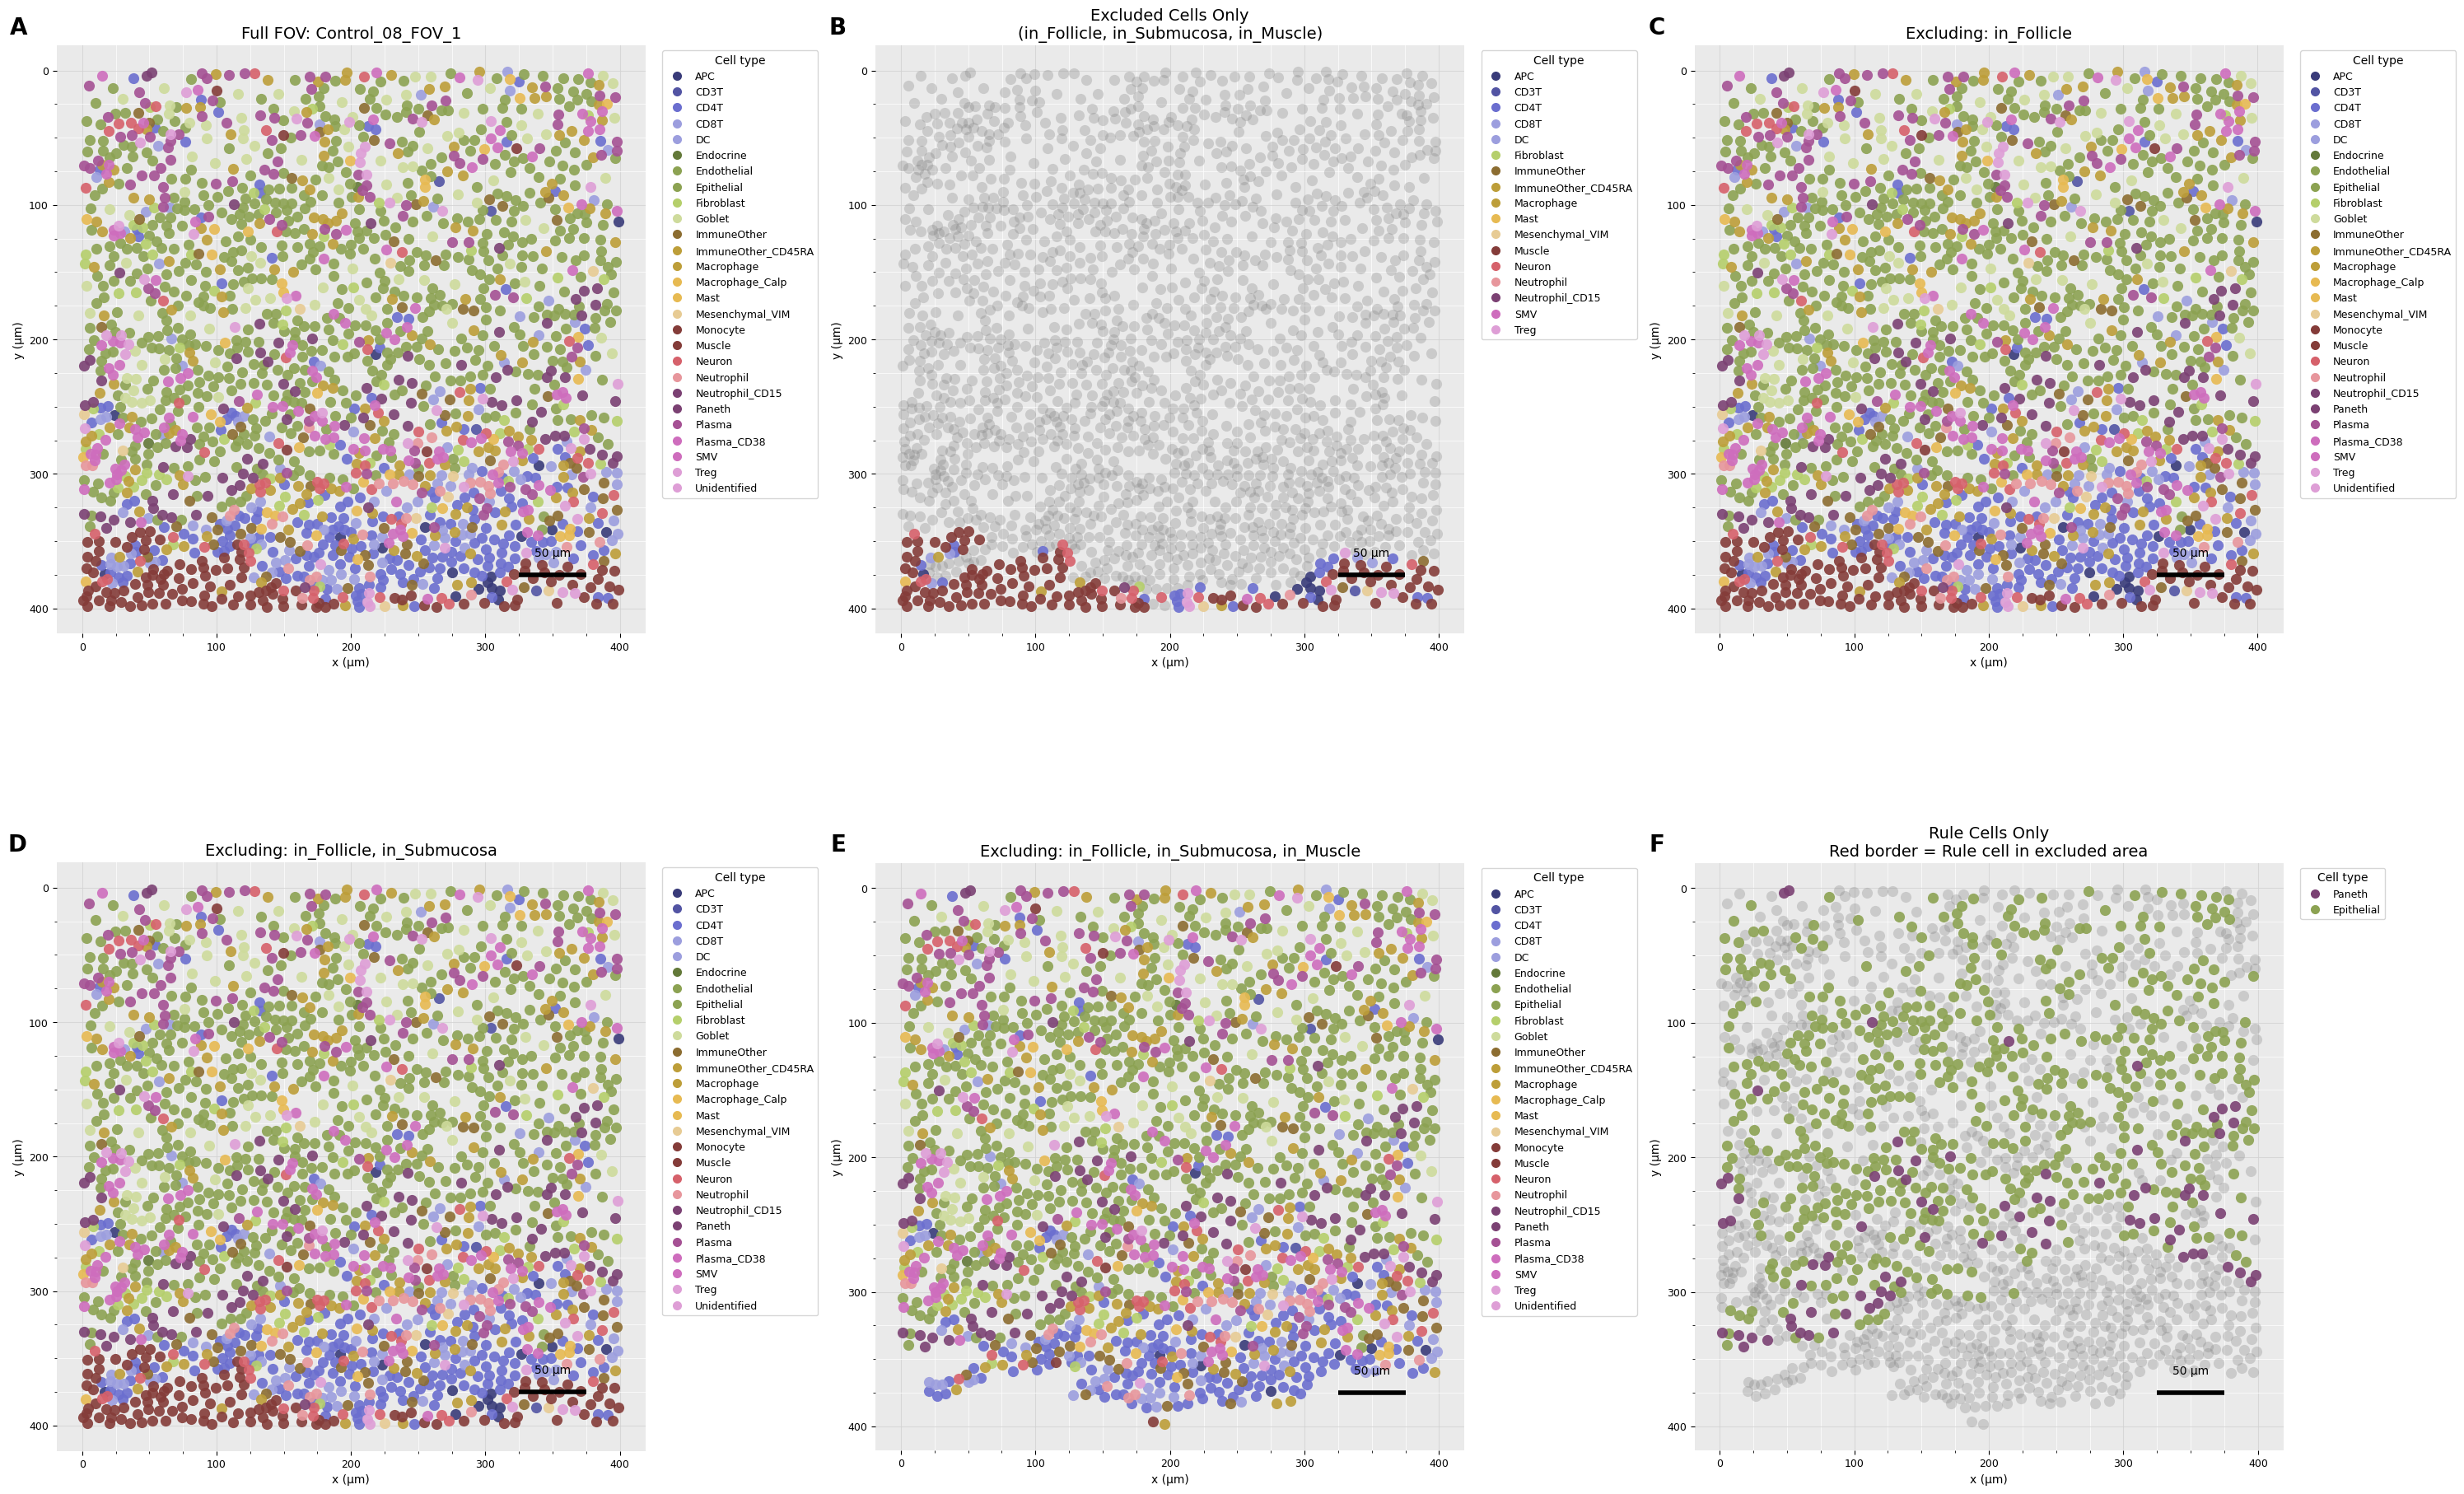

In [22]:
evaluate_cohort_and_exclusion(
    ant_base="Paneth", 
    con_base="Epithelial", 
    excluded_areas=["in_Follicle", "in_Submucosa", "in_Muscle"], 
    organ="Duodenum", 
    stage="Control"
)


Investigating Rule: Paneth -> Epithelial
Organ: Duodenum | Stage: Control_S
Excluded Areas: ['in_Follicle', 'in_Submucosa', 'in_Muscle']

Evaluating 21 FOVs...

FOV: S_01_FOV_1
  [Orig] Trans: 4905  | Sup: 0.0004 | Conf: 1.0000 | Lift: 1.1748 | PASS: False
  [Excl] Trans: 4868  | Sup: 0.0004 | Conf: 1.0000 | Lift: 1.1659 | PASS: False

FOV: S_01_FOV_2
  [Orig] Trans: 6371  | Sup: 0.0009 | Conf: 1.0000 | Lift: 1.5502 | PASS: False
  [Excl] Trans: 6299  | Sup: 0.0010 | Conf: 1.0000 | Lift: 1.5327 | PASS: False

FOV: S_01_FOV_3
  [Orig] Trans: 6583  | Sup: 0.0009 | Conf: 1.0000 | Lift: 1.1344 | PASS: False
  [Excl] Trans: 6583  | Sup: 0.0009 | Conf: 1.0000 | Lift: 1.1344 | PASS: False

FOV: S_01_FOV_4
  [Orig] Trans: 5898  | Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Excl] Trans: 5769  | Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: S_02_FOV_1
  [Orig] Trans: 5844  | Sup: 0.0007 | Conf: 1.0000 | Lift: 1.2595 | PASS: False
  [Excl] Trans: 5681  | Sup: 0.0007

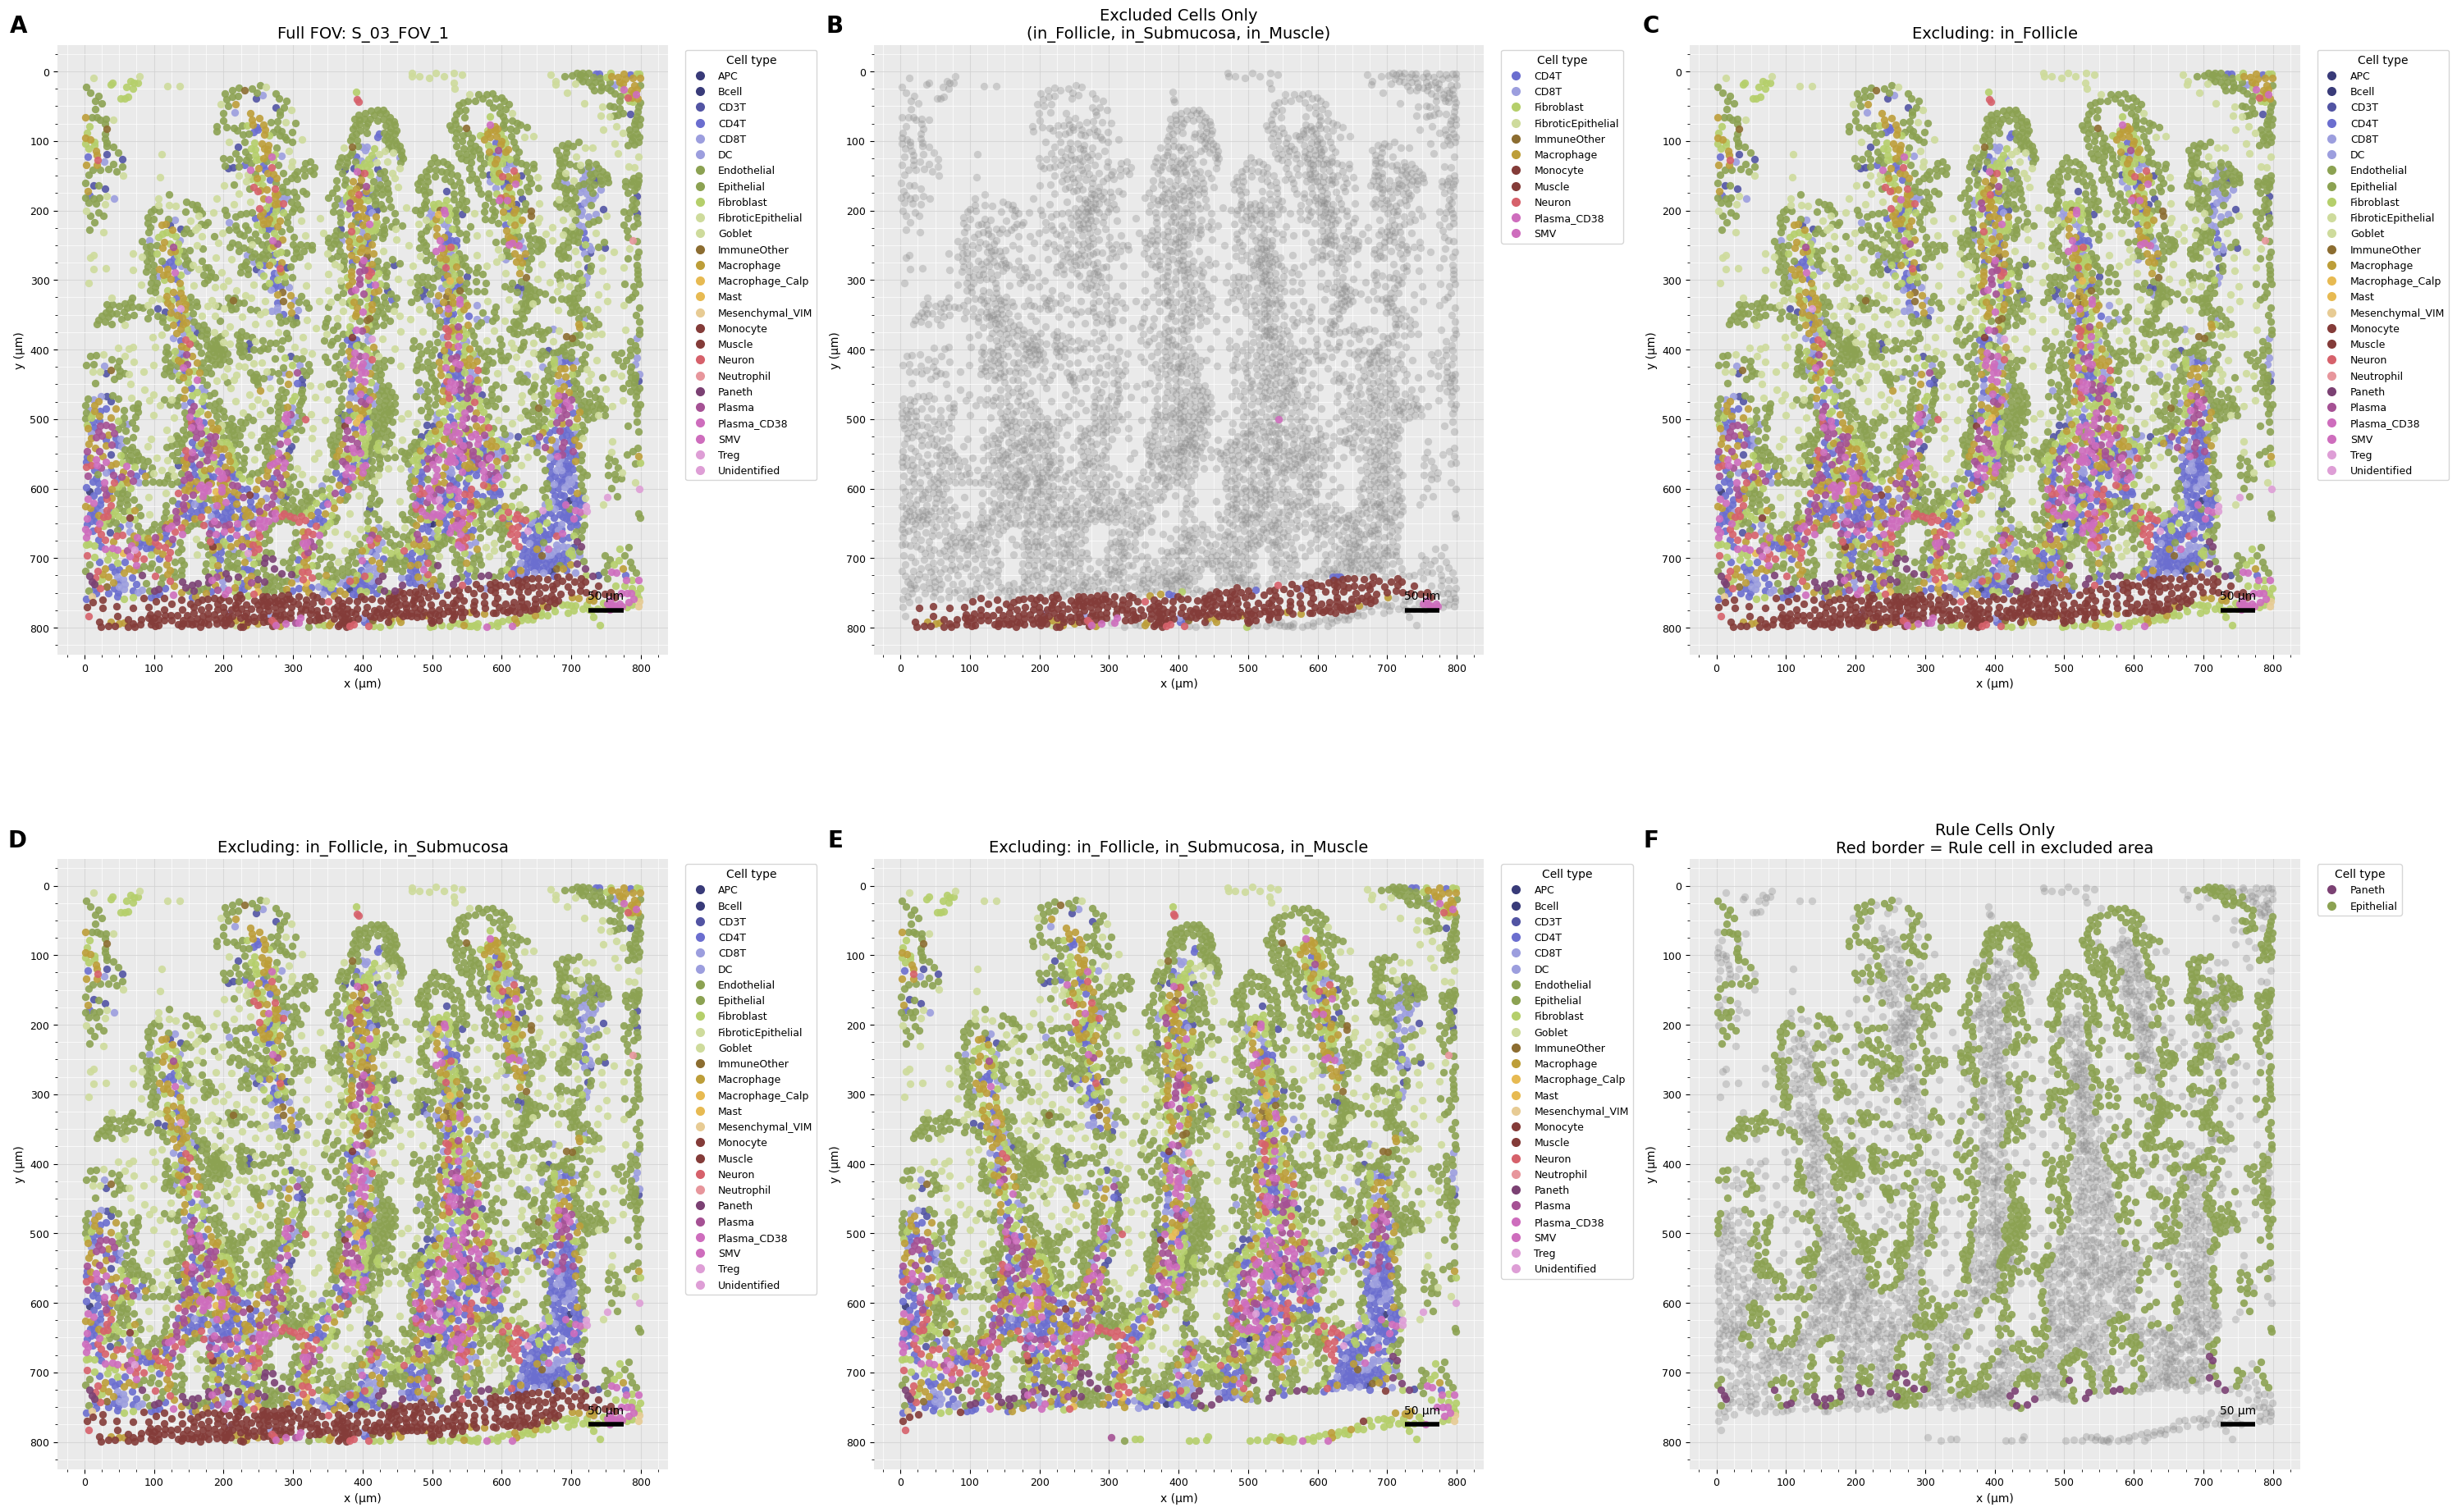

In [23]:
evaluate_cohort_and_exclusion(
    ant_base="Paneth", 
    con_base="Epithelial", 
    excluded_areas=["in_Follicle", "in_Submucosa", "in_Muscle"], 
    organ="Duodenum", 
    stage="Control_S"
)

Investigating Rule: Paneth -> Epithelial
Organ: Duodenum | Stage: Mild
Excluded Areas: ['in_Follicle', 'in_Submucosa', 'in_Muscle']

Evaluating 103 FOVs...

FOV: GVHD_03_FOV_1_R
  [Orig] Trans: 2860  | Sup: 0.0021 | Conf: 1.0000 | Lift: 1.6807 | PASS: False
  [Excl] Trans: 2807  | Sup: 0.0021 | Conf: 1.0000 | Lift: 1.6495 | PASS: False

FOV: GVHD_03_FOV_2
  [Orig] Trans: 2425  | Sup: 0.0173 | Conf: 1.0000 | Lift: 1.7406 | PASS: True
  [Excl] Trans: 2380  | Sup: 0.0176 | Conf: 1.0000 | Lift: 1.7083 | PASS: True

FOV: GVHD_03_FOV_3_R
  [Orig] Trans: 2522  | Sup: 0.0238 | Conf: 1.0000 | Lift: 1.3819 | PASS: True
  [Excl] Trans: 2432  | Sup: 0.0247 | Conf: 1.0000 | Lift: 1.3358 | PASS: True

FOV: GVHD_03_FOV_4
  [Orig] Trans: 2442  | Sup: 0.0147 | Conf: 1.0000 | Lift: 1.4034 | PASS: True
  [Excl] Trans: 2432  | Sup: 0.0148 | Conf: 1.0000 | Lift: 1.3976 | PASS: True

FOV: GVHD_04_FOV_1
  [Orig] Trans: 1639  | Sup: 0.0024 | Conf: 1.0000 | Lift: 1.2450 | PASS: False
  [Excl] Trans: 1427  | Su

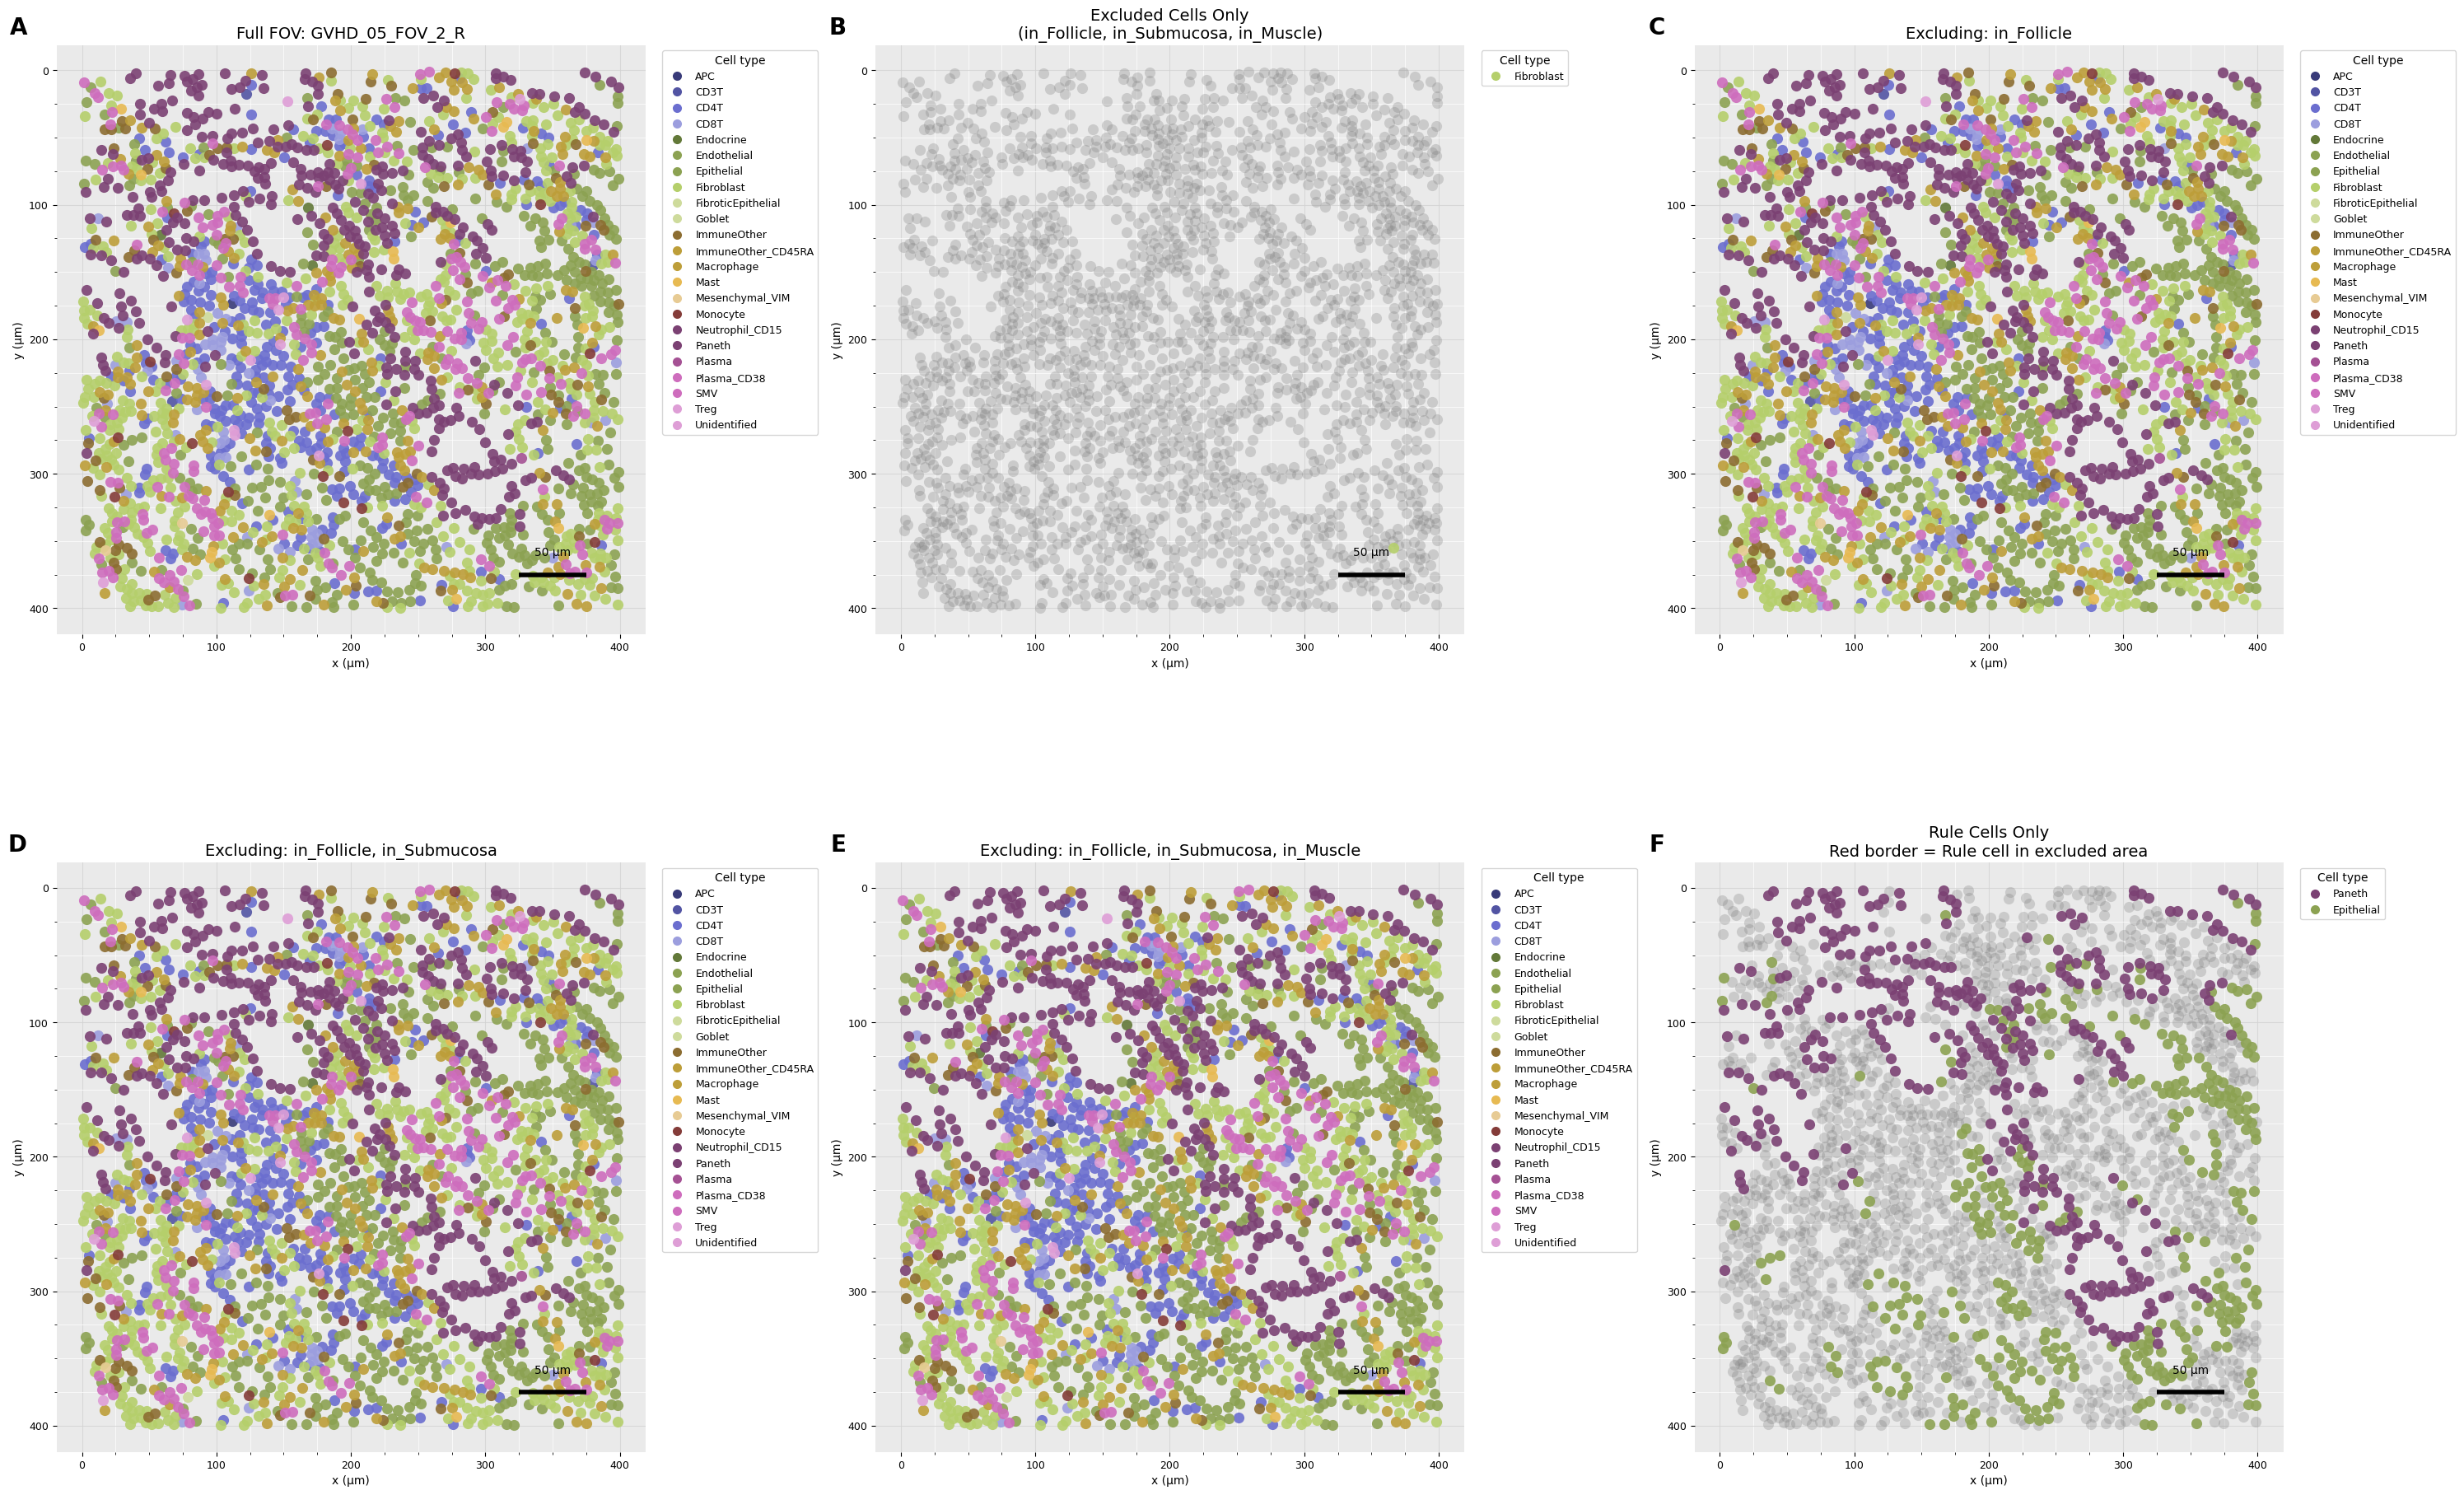

In [24]:
evaluate_cohort_and_exclusion(
    ant_base="Paneth", 
    con_base="Epithelial", 
    excluded_areas=["in_Follicle", "in_Submucosa", "in_Muscle"], 
    organ="Duodenum", 
    stage="Mild"
)

Investigating Rule: Paneth -> Epithelial
Organ: Duodenum | Stage: Severe
Excluded Areas: ['in_Follicle', 'in_Submucosa', 'in_Muscle']

Evaluating 36 FOVs...

FOV: GVHD_02_FOV_1_R
  [Orig] Trans: 1964  | Sup: 0.0869 | Conf: 0.5175 | Lift: 1.0964 | PASS: False
  [Excl] Trans: 1889  | Sup: 0.0904 | Conf: 0.5175 | Lift: 1.0668 | PASS: False

FOV: GVHD_02_FOV_2_R
  [Orig] Trans: 1712  | Sup: 0.0379 | Conf: 0.3690 | Lift: 1.1407 | PASS: False
  [Excl] Trans: 1645  | Sup: 0.0395 | Conf: 0.3690 | Lift: 1.0960 | PASS: False

FOV: GVHD_06_FOV_1
  [Orig] Trans: 2174  | Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Excl] Trans: 2174  | Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_06_FOV_2
  [Orig] Trans: 2265  | Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False
  [Excl] Trans: 2265  | Sup: 0.0000 | Conf: 0.0000 | Lift: 0.0000 | PASS: False

FOV: GVHD_06_FOV_3
  [Orig] Trans: 1933  | Sup: 0.0003 | Conf: 0.3310 | Lift: 2.3671 | PASS: False
  [Excl] Trans: 183

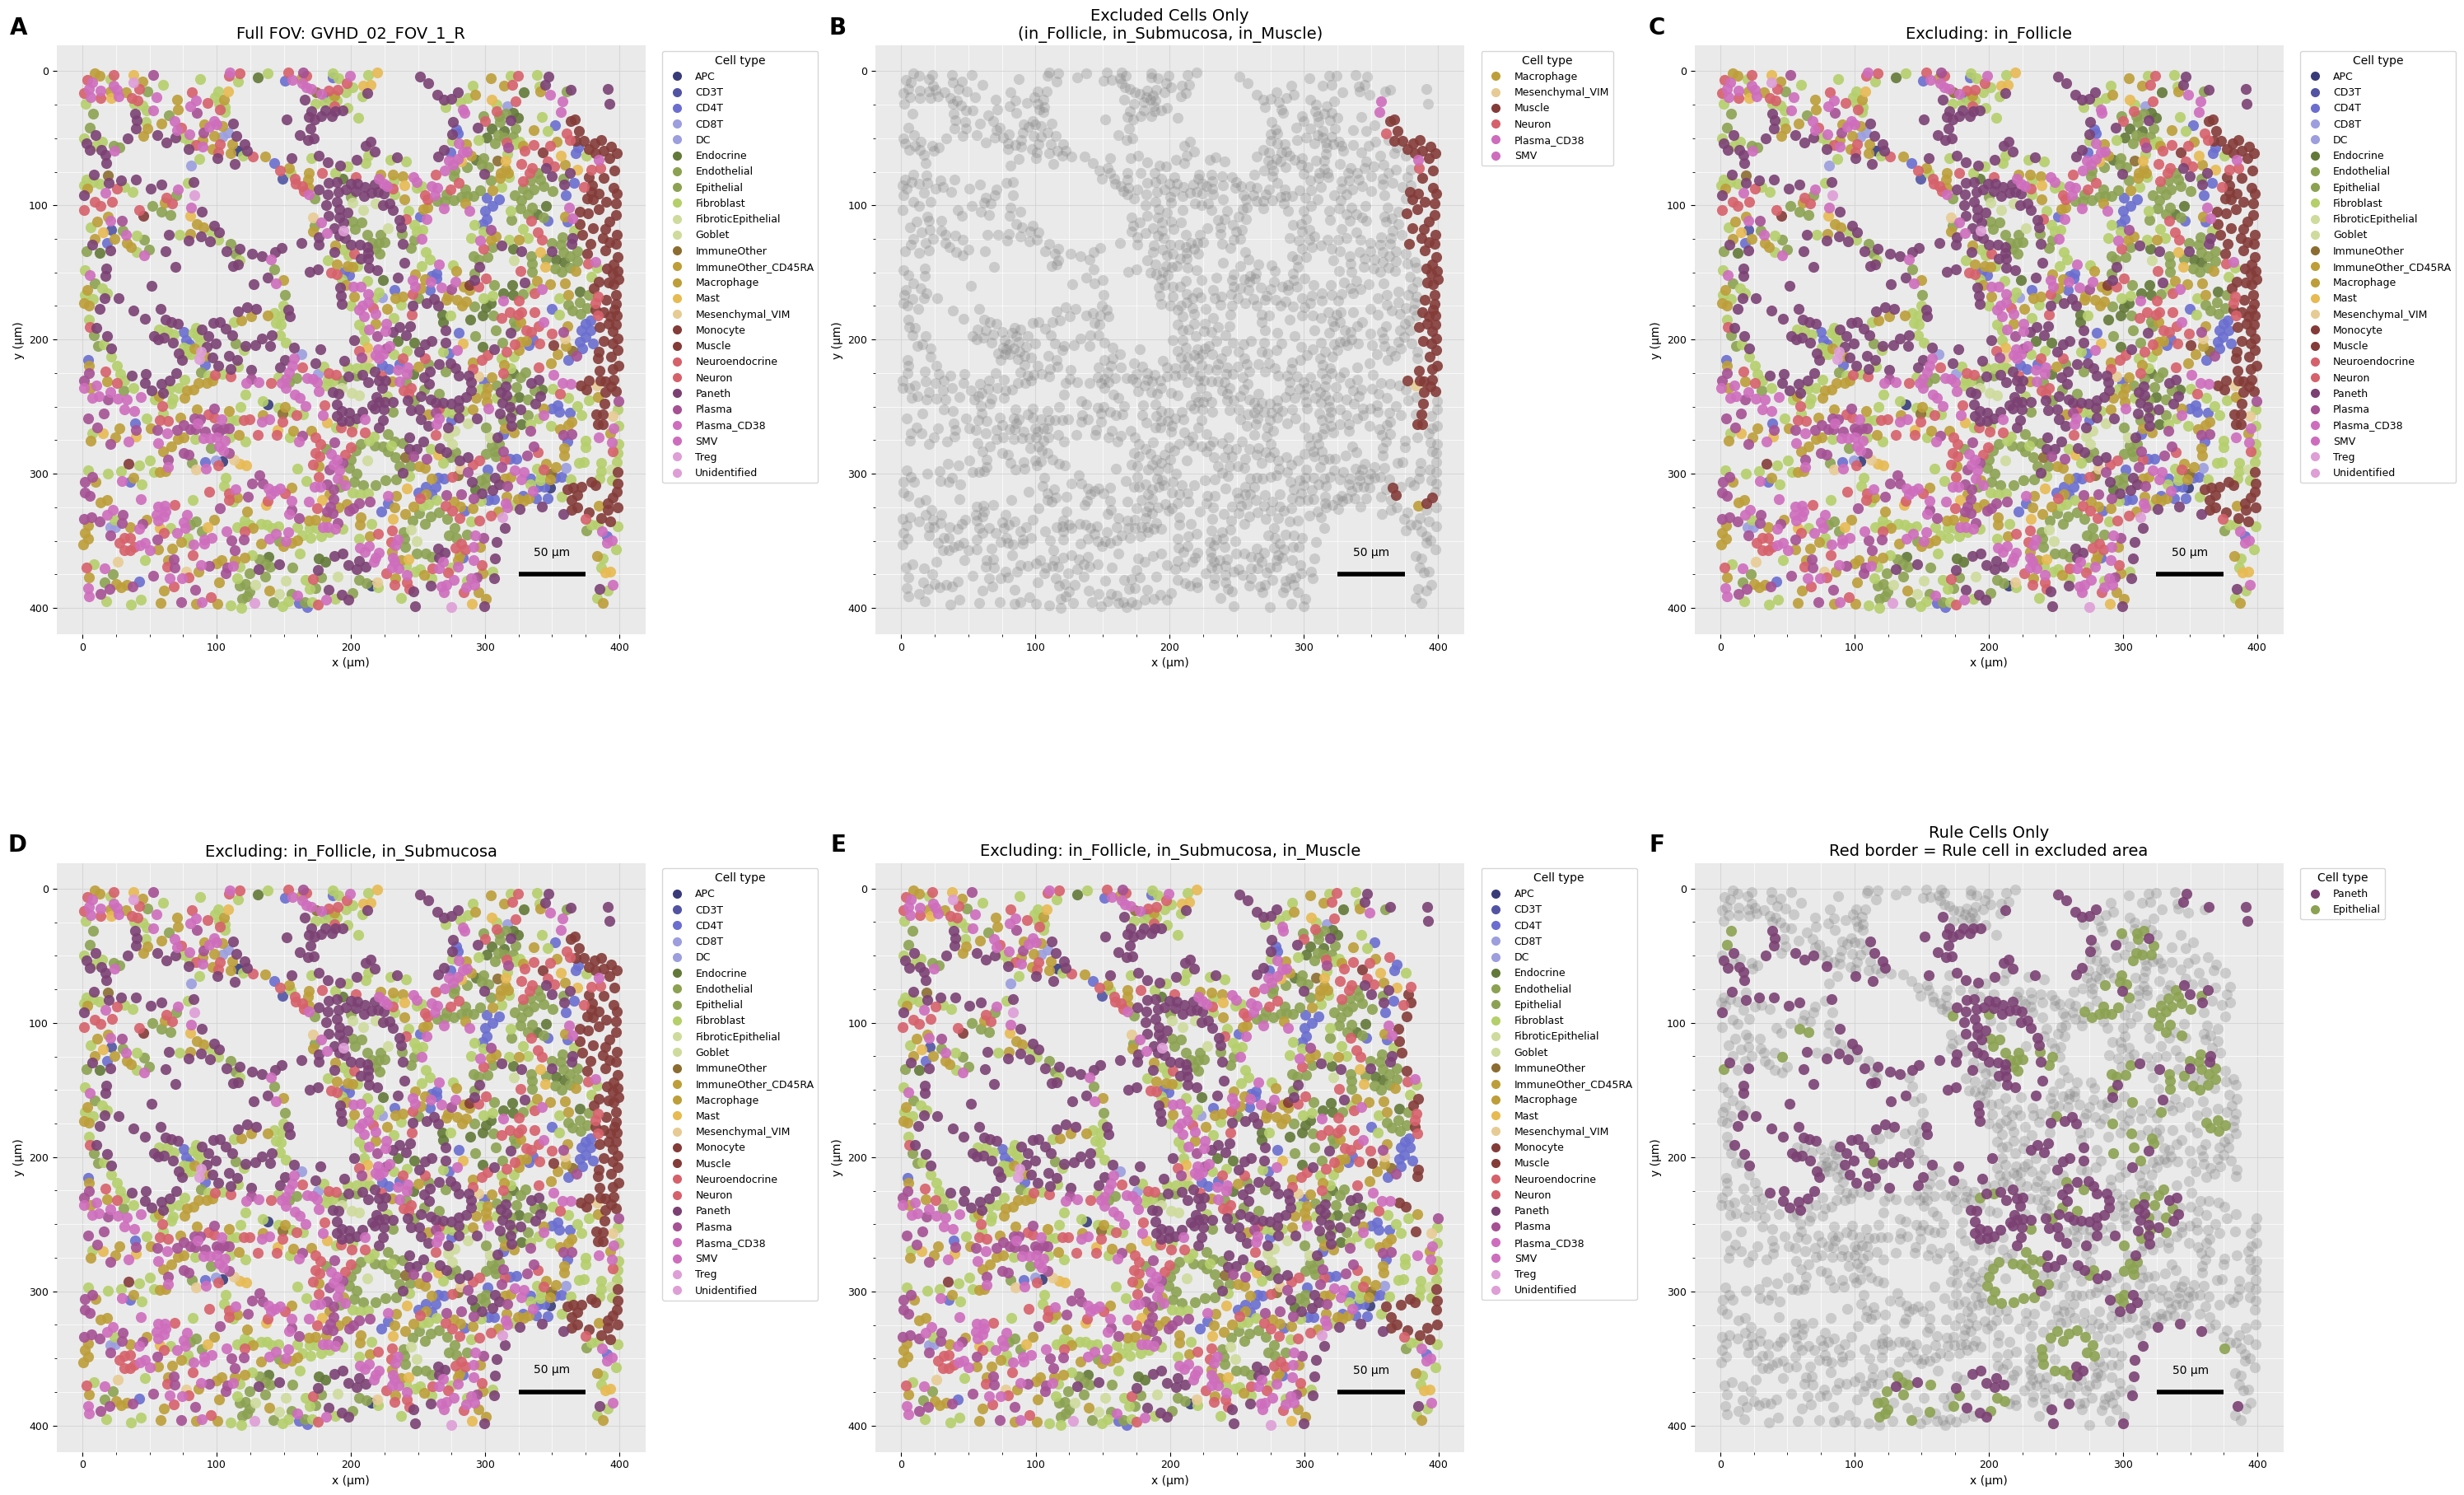

In [25]:
evaluate_cohort_and_exclusion(
    ant_base="Paneth", 
    con_base="Epithelial", 
    excluded_areas=["in_Follicle", "in_Submucosa", "in_Muscle"], 
    organ="Duodenum", 
    stage="Severe"
)